#Sprint 03 - Modelagem Linear para Aprendizado de Máquina

**Integrantes:**

Eduardo Barcelos De Carvalho Braziliano RM:573274

Julia Johanson Peniche Dias Da Silva RM:572220

Lucas Bomfim Leite RM:570420

**Base de dados:** Global EV Charging Stations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import LinearRegression

df = pd.read_csv('ev_stations.csv')

variavel = df['Charging Capacity (kW)']
media = variavel.mean()
desvio_padrao = variavel.std()

##01 - Probabilidade acima da Mediana

In [9]:
mediana = variavel.median()
prob_acima = norm.sf(mediana, loc=media, scale=desvio_padrao) * 100

print(f"Mediana calculada: {mediana:.2f} kW")
print(f"Probabilidade de ocorrência acima da mediana: {prob_acima:.2f}%\n")

if prob_acima < 5:
    print("Classificação do evento: RARO")
elif prob_acima < 20:
    print("Classificação do evento: POUCO PROVÁVEL")
elif prob_acima < 95:
    print("Classificação do evento: PROVÁVEL")
else:
    print("Classificação do evento: QUASE CERTO")

Mediana calculada: 150.00 kW
Probabilidade de ocorrência acima da mediana: 48.22%

Classificação do evento: PROVÁVEL


##02 - Probabilidade no intervalo (média ± 2 desvios-padrão)

In [10]:
limite_inferior = media - (2 * desvio_padrao)
limite_superior = media + (2 * desvio_padrao)

prob_intervalo = (norm.cdf(limite_superior, loc=media, scale=desvio_padrao) -
                   norm.cdf(limite_inferior, loc=media, scale=desvio_padrao)) * 100

print(f"Limites do intervalo: de {limite_inferior:.2f} kW até {limite_superior:.2f} kW")
print(f"Probabilidade de estar neste intervalo: {prob_intervalo:.2f}%")

if prob_intervalo < 5:
    print("Classificação do evento: RARO")
elif prob_intervalo < 20:
    print("Classificação do evento: POUCO PROVÁVEL")
elif prob_intervalo < 95:
    print("Classificação do evento: PROVÁVEL")
else:
    print("Classificação do evento: QUASE CERTO")

Limites do intervalo: de -112.47 kW até 401.01 kW
Probabilidade de estar neste intervalo: 95.45%
Classificação do evento: QUASE CERTO


##03 - Modelagem com Regressão Linear

Coeficiente Angular (Inclinação da reta): 0.000009
Coeficiente Linear (Onde a reta corta o eixo Y): 0.2989



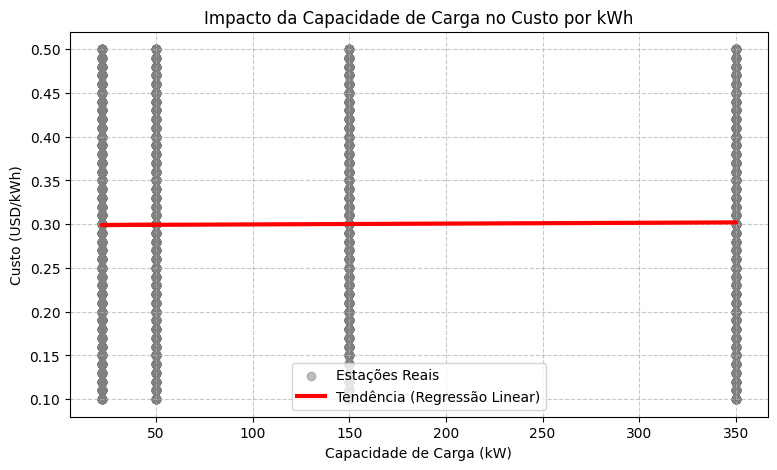

In [11]:
df_reg = df.dropna(subset=['Charging Capacity (kW)', 'Cost (USD/kWh)'])

X = df_reg[['Charging Capacity (kW)']].values
y = df_reg['Cost (USD/kWh)'].values

modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)

print(f"Coeficiente Angular (Inclinação da reta): {modelo.coef_[0]:.6f}")
print(f"Coeficiente Linear (Onde a reta corta o eixo Y): {modelo.intercept_:.4f}\n")

plt.figure(figsize=(9, 5))
plt.scatter(X, y, color='gray', alpha=0.5, label='Estações Reais')
plt.plot(X, y_pred, color='red', linewidth=3, label='Tendência (Regressão Linear)')
plt.title('Impacto da Capacidade de Carga no Custo por kWh')
plt.xlabel('Capacidade de Carga (kW)')
plt.ylabel('Custo (USD/kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Interpretação dos Coeficientes da Regressão Linear

* **Coeficiente Angular (0.000009):** Este valor representa a inclinação da reta ajustada pelo modelo. Ele indica que, para cada aumento de 1 kW na capacidade de carga da estação, o custo estimado aumenta em um valor ínfimo de 0.000009 USD/kWh. Como esse valor é praticamente zero, a reta fica quase horizontal, o que significa que o aumento da capacidade de carga (kW) praticamente **não impacta** no custo final cobrado por kWh.
* **Coeficiente Linear (0.2989):** Este é o intercepto, ou seja, o ponto onde a reta corta o eixo Y. Ele indica qual é o valor base estimado para o custo. Desconsiderando a influência da capacidade de carga (se kW fosse 0), o modelo estabelece que o custo base médio da energia gira em torno de 0.2989 USD/kWh.


## 04 - Organização, clareza e interpretação geral



**Relação entre Estatística e Aprendizado de Máquina:**
Neste projeto, utilizamos as duas abordagens de forma complementar para extrair insights da base de dados.

A aplicação de conceitos de **Estatística Descritiva e Probabilidade** (cálculos de mediana, média, desvio-padrão e Distribuição Normal) foi fundamental para compreendermos a estrutura da nossa variável principal de estudo. Com isso, conseguimos mapear a distribuição dos dados e calcular a probabilidade de eventos específicos, identificando o que é um comportamento padrão (Quase Certo) e o que são valores atípicos (Raros) no universo das estações de recarga elétrica.

Por outro lado, a aplicação do modelo de **Machine Learning (Regressão Linear)** nos permitiu dar um passo além da observação isolada: passamos a investigar a relação e a dependência entre duas variáveis distintas (Capacidade em kW vs. Custo em USD). Enquanto a estatística nos descreveu o formato e a dispersão dos dados, o modelo de aprendizado de máquina tentou encontrar um padrão preditivo, o qual nos revelou matematicamente (através de coeficientes próximos a zero) uma ausência de correlação forte, provando que estações mais potentes não necessariamente cobram mais caro pela energia.